# MNIST + EMNIST: interfacing and building class subsets

This notebook shows how to load both datasets through `harpl.data` and how to
build sub-datasets that only contain a chosen set of classes.

- **Digits (0-9)** come from **MNIST**.
- **Letters (a-z)** come from **EMNIST** (the `letters` split of the NIST
  handwriting database, reformatted by NIST/torchvision to look like MNIST).

Both are loaded as plain `(images, labels)` tensor pairs via
`harpl.data.load_mnist` / `harpl.data.load_emnist`, and then filtered down to
specific classes with `harpl.data.ClassSubsetDataset`.

One gotcha: EMNIST's raw arrays are stored transposed relative to MNIST
(a well-known quirk of how NIST packaged the data). `load_emnist` corrects
this for you, so images come out right-side-up and consistent with MNIST.

In [ ]:
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from torchvision import make_grid

from harpl.ours import (
    ClassSubsetDataset,
    DIGIT_CLASSES,
    LETTER_CLASSES,
    letters_to_labels,
    load_emnist,
    load_mnist,
)

# Shared root for on-disk datasets (see ./datasets/mnist, ./datasets/emnist at repo root)
DATA_ROOT = "../../../datasets"

## 1. Load each dataset

`load_mnist` / `load_emnist` download the raw torchvision dataset (if needed)
and return `(images, labels)` as plain tensors, normalized to `[0, 1]`:

- MNIST: `images` is `(N, 28, 28)`, `labels` is `0-9`.
- EMNIST: `images` is `(N, 28, 28)`, `labels` is `1-26` (`a=1, b=2, ..., z=26`).

In [5]:
mnist_images, mnist_labels = load_mnist(DATA_ROOT, train=True, download=True)
emnist_images, emnist_labels = load_emnist(DATA_ROOT, train=True, download=True)

print("MNIST :", mnist_images.shape, mnist_images.dtype, "labels", mnist_labels.min().item(), "-", mnist_labels.max().item())
print("EMNIST:", emnist_images.shape, emnist_images.dtype, "labels", emnist_labels.min().item(), "-", emnist_labels.max().item())

MNIST : torch.Size([60000, 28, 28]) torch.float32 labels 0 - 9
EMNIST: torch.Size([124800, 28, 28]) torch.float32 labels 1 - 26


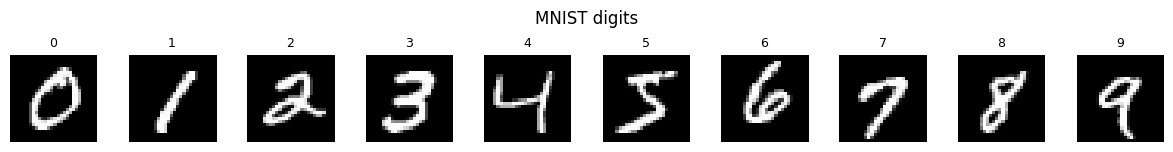

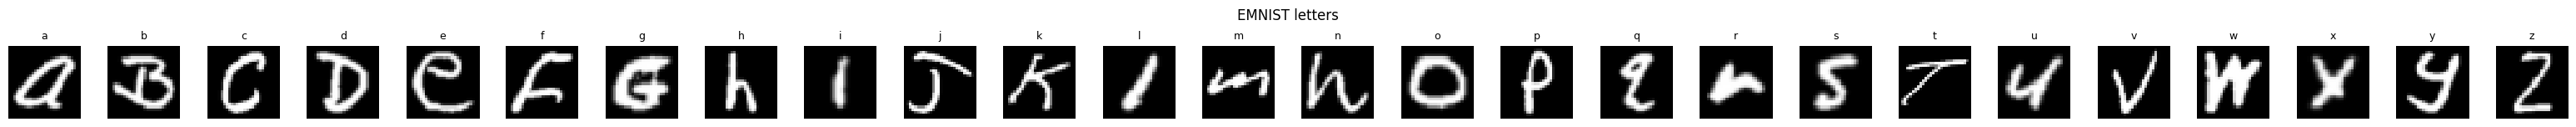

In [6]:
def show_one_per_class(images, labels, classes, class_names, title):
    fig, axes = plt.subplots(1, len(classes), figsize=(1.2 * len(classes), 1.5))
    for ax, cls, name in zip(axes, classes, class_names):
        idx = (labels == cls).nonzero()[0].item()
        ax.imshow(images[idx], cmap="gray")
        ax.set_title(name, fontsize=9)
        ax.axis("off")
    fig.suptitle(title)
    fig.tight_layout()


show_one_per_class(mnist_images, mnist_labels, DIGIT_CLASSES, [str(d) for d in DIGIT_CLASSES], "MNIST digits")
show_one_per_class(emnist_images, emnist_labels, letters_to_labels(LETTER_CLASSES), LETTER_CLASSES, "EMNIST letters")

## 2. Build sub-datasets restricted to certain classes

`ClassSubsetDataset(images, labels, classes)` filters down to only the given
classes and remaps their labels to a contiguous `0..len(classes)-1` range (in
the order `classes` is given), so a downstream classifier head only needs as
many outputs as classes you selected.

- For **digits**, pass MNIST labels directly (`0-9`).
- For **letters**, convert letters to EMNIST label ids first with
  `letters_to_labels(...)`.

digit_subset: 30145 images, 5 classes
  new label 0 <- digit 2
  new label 1 <- digit 3
  new label 2 <- digit 4
  new label 3 <- digit 7
  new label 4 <- digit 9


(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

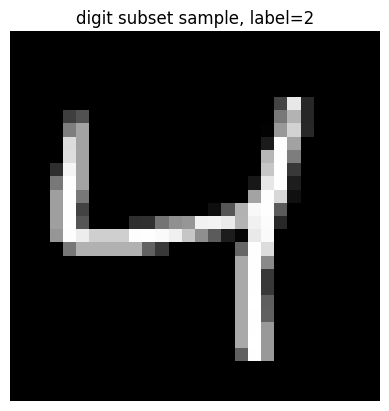

In [ ]:
# Only digits 3, 7, 9 -> remapped to labels 0, 1, 2 respectively
digit_subset = ClassSubsetDataset(mnist_images, mnist_labels, classes=[2, 3, 4, 7, 9])

print(f"digit_subset: {len(digit_subset)} images, {len(digit_subset.classes)} classes")
for new_label, orig_class in enumerate(digit_subset.classes):
    print(f"  new label {new_label} <- digit {orig_class}")

image, label = digit_subset[0]
plt.imshow(image, cmap="gray")
plt.title(f"digit subset sample, label={label.item()}")
plt.axis("off")

letter_subset: 24000 images, 5 classes
  new label 0 <- letter 'T'
  new label 1 <- letter 'Y'
  new label 2 <- letter 'W'
  new label 3 <- letter 'K'
  new label 4 <- letter 'R'


(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

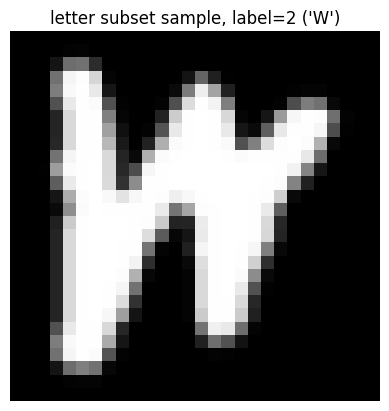

In [ ]:
# Only letters a, m, z -> remapped to labels 0, 1, 2 respectively
selected_letters = ["T", "Y", "W", "K", "R"]
letter_subset = ClassSubsetDataset(emnist_images, emnist_labels, classes=letters_to_labels(selected_letters))

print(f"letter_subset: {len(letter_subset)} images, {len(letter_subset.classes)} classes")
for new_label, letter in zip(range(len(letter_subset.classes)), selected_letters):
    print(f"  new label {new_label} <- letter '{letter}'")

image, label = letter_subset[0]
plt.imshow(image, cmap="gray")
plt.title(f"letter subset sample, label={label.item()} ('{selected_letters[label.item()]}')")
plt.axis("off")

## 3. Use a sub-dataset in a `DataLoader`

`ClassSubsetDataset` is a regular `torch.utils.data.Dataset`, so it plugs
straight into a `DataLoader` like any other dataset.

In [ ]:
loader = DataLoader(digit_subset, batch_size=8, shuffle=True)
images, labels = next(iter(loader))
print("batch:", images.shape, labels.shape, "labels:", labels.tolist())

batch: torch.Size([8, 28, 28]) torch.Size([8]) labels: [1, 3, 2, 3, 3, 4, 1, 0]
